# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! pip install -i https://test.pypi.org/simple/ my_krml_25548684_at1==0.2.6

Looking in indexes: https://test.pypi.org/simple/



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [4]:
# Open-Meteo Setup
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries from custom package
from my_krml_25548684_at1.data.sets import *
from my_krml_25548684_at1.plots.numeric import *
from my_krml_25548684_at1.features.num_cat import *
from my_krml_25548684_at1.features.null import *
from my_krml_25548684_at1.models.performance import *

# Import libraries for Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

# Import libraries for Creating pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Import libraries for Data Transformation
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Import libraries for Saving models and pipelines
import joblib
import cloudpickle
from pathlib import Path

## 1. Declaring Constants

In [5]:
# Latitude and Longitude Coordinates for Sydney
LAT, LON = -33.8678, 151.2073

# Dataset URL
DATASET_URL = "https://archive-api.open-meteo.com/v1/archive"

# Start and End Date
START_DATE, END_DATE = "2010-01-01", "2024-12-31"

# Timezone
TIMEZONE = "Australia/Sydney"

---
## A. Project Description


In [1]:
# <Student to fill this section>
student_name = "Gowtham Kamasamudra Prasanna"
student_id = "25390156"

In [3]:
# Do not modify this code
print("Student",student_name,"\nstudent_id",student_id)

Student Gowtham Kamasamudra Prasanna 
student_id 25390156


---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """
The goal of this project is to build a machine learning model that predicts whether it will rain in Sydney exactly seven days ahead. Unlike traditional forecasts, this classification 
approach adapts to historical data patterns, improving accuracy in micro-climates where rule-based models often fail. By exposing predictions through scalable APIs, businesses can 
automate workflows and integrate forecasts seamlessly into their decision-making processes. Accurate rain/no-rain predictions support risk management, optimize scheduling, and 
strengthen resilience across industries such as agriculture, logistics, energy, and event management. This capability helps Open Meteo position itself competitively as a provider 
of reliable, API-driven climate intelligence.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
# <Student to fill this section>
business_objectives = """
Accurate results will directly influence operational planning and cost efficiency across industries. For farmers, correct predictions enable timely irrigation and crop protection, 
while event managers can avoid disruptions by planning contingencies. For logistics and energy sectors, accurate rain forecasts help optimize scheduling and demand planning. However, 
incorrect results can lead to financial losses, resource waste, and reputational damage for both clients and Open Meteo. A false positive may trigger unnecessary precautions, while a 
false negative could cause unpreparedness. Therefore, the objective is to maximize prediction accuracy to minimize risks, boost client trust, and deliver actionable insights aligned 
with enterprise needs.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The classification results will be consumed primarily through predictive APIs, enabling clients to integrate forecasts into real-time workflows. Internal stakeholders such as 
Open Meteo’s CTO and product teams expect scalable, API-ready models deployable on Render. External stakeholders, including enterprise clients, expect reliable outputs with minimal 
latency and seamless integration into their systems. Business stakeholders—such as farmers, insurers, logistics providers, and event managers—expect forecasts that minimize uncertainty,
reduce costs, and improve operational resilience. Accurate predictions directly impact their planning decisions, making the model a crucial decision-support tool. Overall, stakeholders 
expect trustworthiness, scalability, and practical usability from the system.
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets
> For this part of the assignment, I'll be pulling daily weather data directly from the Open-Meteo API. Since we're dealing with a 'Yes / No' outcome at the day level, daily variables are the most relevant for this project.

> After significant research, I found that rainfall prediction usually relies on insights from meteorologists and atmospheric scientists, who consider the following factors:  
>  
> - Temperature  
> - Moisture and Humidity Levels  
> - Cloud Cover and Sunshine  
> - Wind Patterns  
> - Atmospheric Pressure  
> - Energy and Evapotranspiration  
> - Visibility and Atmospheric Instability
>
> These variables help give a clearer picture of the conditions that lead to rain.

In [15]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [16]:
# Daily Features

daily_vars = [
    # Temperature
    "apparent_temperature_max", "apparent_temperature_min", "apparent_temperature_mean", "temperature_2m_max", "temperature_2m_min", 
    "temperature_2m_mean", "wet_bulb_temperature_2m_mean", "wet_bulb_temperature_2m_max", "wet_bulb_temperature_2m_min", 
    
    # Moisture & humidity
    "relative_humidity_2m_mean", "relative_humidity_2m_max", "relative_humidity_2m_min", "dew_point_2m_mean", 
    
    # Clouds & sunshine
    "cloud_cover_mean", "cloud_cover_max", "sunshine_duration",
    
    # Wind
    "wind_speed_10m_max", "wind_speed_10m_mean", "wind_speed_10m_min", "wind_direction_10m_dominant",
    
    # Pressure & atmosphere
    "pressure_msl_mean", "pressure_msl_max", "pressure_msl_min", "surface_pressure_mean",
    
    # Energy
    "shortwave_radiation_sum", "et0_fao_evapotranspiration",
    
    # Target
    "rain_sum"
]

In [17]:
# Build API request params

params = {
	"latitude": LAT,
	"longitude": LON,
	"daily": daily_vars,
	"timezone": "Australia/Sydney",
	"start_date": START_DATE,
	"end_date": END_DATE,
}

In [18]:
# Fetch data from Open-Meteo
responses = openmeteo.weather_api(DATASET_URL, params=params)

In [19]:
# Location data from the response
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

Coordinates: -33.84885787963867°N 151.1955108642578°E
Elevation: 51.0 m asl
Timezone: b'Australia/Sydney'b'GMT+10'
Timezone difference to GMT+0: 36000s


In [20]:
# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_apparent_temperature_max = daily.Variables(0).ValuesAsNumpy()
daily_apparent_temperature_min = daily.Variables(1).ValuesAsNumpy()
daily_apparent_temperature_mean = daily.Variables(2).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(3).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(4).ValuesAsNumpy()
daily_temperature_2m_mean = daily.Variables(5).ValuesAsNumpy()
daily_wet_bulb_temperature_2m_mean = daily.Variables(6).ValuesAsNumpy()
daily_wet_bulb_temperature_2m_max = daily.Variables(7).ValuesAsNumpy()
daily_wet_bulb_temperature_2m_min = daily.Variables(8).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(9).ValuesAsNumpy()
daily_relative_humidity_2m_max = daily.Variables(10).ValuesAsNumpy()
daily_relative_humidity_2m_min = daily.Variables(11).ValuesAsNumpy()
daily_dew_point_2m_mean = daily.Variables(12).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(13).ValuesAsNumpy()
daily_cloud_cover_max = daily.Variables(14).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(15).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(16).ValuesAsNumpy()
daily_wind_speed_10m_mean = daily.Variables(17).ValuesAsNumpy()
daily_wind_speed_10m_min = daily.Variables(18).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(19).ValuesAsNumpy()
daily_pressure_msl_mean = daily.Variables(20).ValuesAsNumpy()
daily_pressure_msl_max = daily.Variables(21).ValuesAsNumpy()
daily_pressure_msl_min = daily.Variables(22).ValuesAsNumpy()
daily_surface_pressure_mean = daily.Variables(23).ValuesAsNumpy()
daily_shortwave_radiation_sum = daily.Variables(24).ValuesAsNumpy()
daily_et0_fao_evapotranspiration = daily.Variables(25).ValuesAsNumpy()
daily_rain_sum = daily.Variables(26).ValuesAsNumpy()

daily_data = {
                "date": pd.date_range(
                                    	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
                                    	end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
                                    	freq = pd.Timedelta(seconds = daily.Interval()),
                                    	inclusive = "left"
                                     ).tz_convert("Australia/Sydney")
            }

daily_data["apparent_temperature_max"] = daily_apparent_temperature_max
daily_data["apparent_temperature_min"] = daily_apparent_temperature_min
daily_data["apparent_temperature_mean"] = daily_apparent_temperature_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["wet_bulb_temperature_2m_mean"] = daily_wet_bulb_temperature_2m_mean
daily_data["wet_bulb_temperature_2m_max"] = daily_wet_bulb_temperature_2m_max
daily_data["wet_bulb_temperature_2m_min"] = daily_wet_bulb_temperature_2m_min
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["relative_humidity_2m_max"] = daily_relative_humidity_2m_max
daily_data["relative_humidity_2m_min"] = daily_relative_humidity_2m_min
daily_data["dew_point_2m_mean"] = daily_dew_point_2m_mean
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean
daily_data["cloud_cover_max"] = daily_cloud_cover_max
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean
daily_data["wind_speed_10m_min"] = daily_wind_speed_10m_min
daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant
daily_data["pressure_msl_mean"] = daily_pressure_msl_mean
daily_data["pressure_msl_max"] = daily_pressure_msl_max
daily_data["pressure_msl_min"] = daily_pressure_msl_min
daily_data["surface_pressure_mean"] = daily_surface_pressure_mean
daily_data["shortwave_radiation_sum"] = daily_shortwave_radiation_sum
daily_data["et0_fao_evapotranspiration"] = daily_et0_fao_evapotranspiration
daily_data["rain_sum"] = daily_rain_sum

In [21]:
df = pd.DataFrame(data = daily_data)
df.head()

,date,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,temperature_2m_max,temperature_2m_min,temperature_2m_mean,wet_bulb_temperature_2m_mean,wet_bulb_temperature_2m_max,wet_bulb_temperature_2m_min,...,wind_speed_10m_mean,wind_speed_10m_min,wind_direction_10m_dominant,pressure_msl_mean,pressure_msl_max,pressure_msl_min,surface_pressure_mean,shortwave_radiation_sum,et0_fao_evapotranspiration,rain_sum
0,2010-01-01 01:00:00+11:00,26.715891,24.240879,25.151611,25.670502,21.070499,22.964251,20.643309,21.304327,19.931772,...,10.419551,4.072935,331.647491,1011.920837,1014.099976,1009.500000,1005.987488,10.130000,2.459723,3.9
1,2010-01-02 01:00:00+11:00,32.614998,22.179842,26.942467,26.920502,20.970501,23.612165,21.520597,23.316803,19.692732,...,8.355687,1.297998,298.610291,1007.470764,1011.000000,1003.900024,1001.576172,23.620001,4.571662,8.6
2,2010-01-03 01:00:00+11:00,21.280840,19.180962,19.709002,20.620499,19.470501,19.882996,16.673801,19.032654,15.879213,...,12.964748,6.915374,146.744644,1015.529236,1019.500000,1011.099976,1009.512390,6.710000,2.140701,1.1
3,2010-01-04 01:00:00+11:00,22.343325,19.466248,21.016272,22.520500,19.220501,20.887167,17.092829,17.960951,15.985977,...,11.067534,5.623380,69.884773,1019.012390,1020.700012,1017.200012,1012.995667,15.840000,3.498662,0.6
4,2010-01-05 01:00:00+11:00,30.018890,19.811029,24.393919,26.020500,18.620499,22.520498,19.079020,21.130150,16.724476,...,9.724721,4.334974,35.137077,1015.891663,1018.299988,1013.000000,1009.925781,30.139999,5.620671,0.0


### C.2 Define Target variable

In [22]:
# Define the target variable
target_name = 'rain_in_7d'

In [23]:
# <Student to fill this section>
target_definition_explanations = """
The target variable rain_in_7d is defined as a binary indicator of whether rainfall occurs exactly seven days after a given date. This aligns with the business use case of 
providing actionable yes/no forecasts to support planning, where users need certainty on rain occurrence rather than volume.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [25]:
# Create the target variable
shifted = df["rain_sum"].shift(-7)
df[target_name] = (shifted > 0).astype(float).where(shifted.notna())

In [26]:
# Drop the feature to prevent data leakage
df.drop(columns = "rain_sum", inplace = True)

### C.4 Explore Target variable

In [27]:
# Display descriptive statistics
df[target_name].describe()

count    5472.000000
mean        0.524123
std         0.499463
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: rain_in_7d, dtype: float64

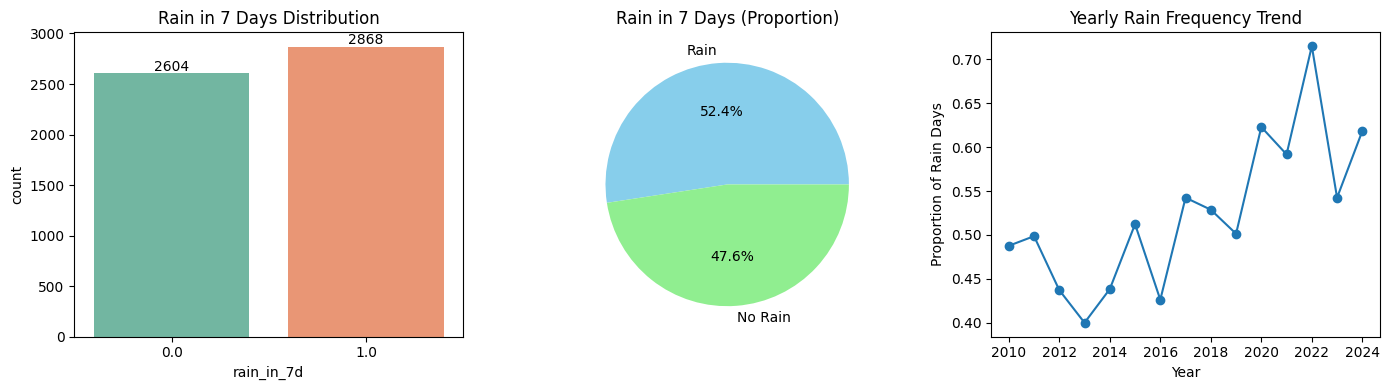

In [28]:
plt.figure(figsize=(14,4))

# Distribution
plt.subplot(1,3,1)
ax = sns.countplot(x = target_name, data = df, palette = 'Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')
plt.title("Rain in 7 Days Distribution")

# Pie chart
plt.subplot(1,3,2)
df[target_name].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Rain', 'No Rain'], colors=['skyblue', 'lightgreen']
)
plt.title("Rain in 7 Days (Proportion)")
plt.ylabel("")

# Line plot: trend over time
plt.subplot(1,3,3)
df.groupby(df['date'].dt.year)[target_name].mean().plot(marker='o')
plt.title("Yearly Rain Frequency Trend")
plt.xlabel("Year")
plt.ylabel("Proportion of Rain Days")

plt.tight_layout()
plt.show()

In [29]:
# <Student to fill this section>
target_distribution_explanations = """
The dataset shows a near-balanced distribution, with 2,604 instances of no rain and 2,868 of rain within seven days, confirmed by a mean value of 0.524. The pie chart indicates 
rain occurs 52.4% of the time, highlighting the need for accurate classification beyond majority-class prediction. The trend chart reveals a gradual increase in rain frequency 
since 2010, peaking above 70% around 2022. Despite annual fluctuations, this upward trajectory suggests a long-term shift towards more frequent rain events, indicating that temporal 
features could improve model performance.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `cloud_cover_mean`

In [31]:
# Assign the feature name 'cloud_cover_mean' to the variable feat_1
feat_1 = "cloud_cover_mean"

In [32]:
# Display descriptive statistics
df[feat_1].describe()

count    5479.000000
mean       48.330826
std        29.580282
min         0.000000
25%        23.979167
50%        47.791668
75%        72.125000
max       100.000000
Name: cloud_cover_mean, dtype: float64

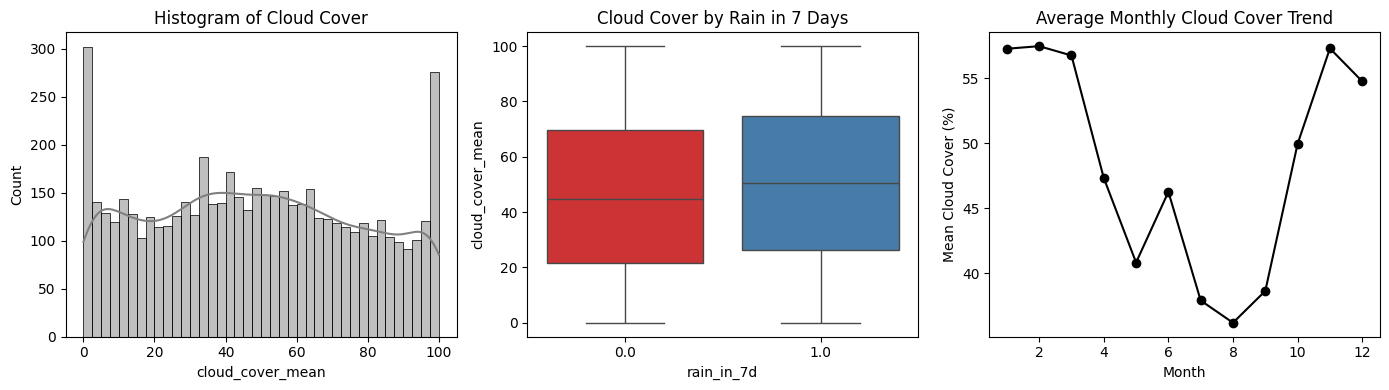

In [33]:
plt.figure(figsize=(14,4))

# Histogram
plt.subplot(1,3,1)
sns.histplot(df[feat_1], bins = 40, kde = True, color = 'gray')
plt.title("Histogram of Cloud Cover")

# Box vs Target
plt.subplot(1,3,2)
sns.boxplot(x = target_name, y = feat_1, data = df, palette = 'Set1')
plt.title("Cloud Cover by Rain in 7 Days")

# Line plot monthly trend
plt.subplot(1,3,3)
df.groupby(df['date'].dt.month)[feat_1].mean().plot(marker = 'o', color = 'black')
plt.title("Average Monthly Cloud Cover Trend")
plt.xlabel("Month")
plt.ylabel("Mean Cloud Cover (%)")

plt.tight_layout()
plt.show()

In [34]:
# <Student to fill this section>
feature_2_insights = """
The histogram shows a fairly uniform distribution of average cloud cover, with peaks at 0% and 100%, indicating frequent clear and overcast days, while most values fall 
between 60–80%, suggesting moderate-to-high cloudiness. The boxplot indicates higher cloud cover medians and wider spreads on rainy days, showing a positive association 
with rain within seven days. Seasonal patterns are evident, with cloudiness peaking in early (Jan–Mar) and late (Nov–Dec) months and dipping mid-year (Jul–Aug), reflecting 
cyclical regional weather variations.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `wind_speed_10m_mean`


In [36]:
# Assign the feature name 'wind_speed_10m_mean' to the variable feat_2
feat_2 = "wind_speed_10m_mean"

In [37]:
# Display descriptive statistics
df[feat_2].describe()

count    5479.000000
mean       11.929917
std         4.588791
min         3.419965
25%         8.544684
50%        10.986862
75%        14.487136
max        37.387234
Name: wind_speed_10m_mean, dtype: float64

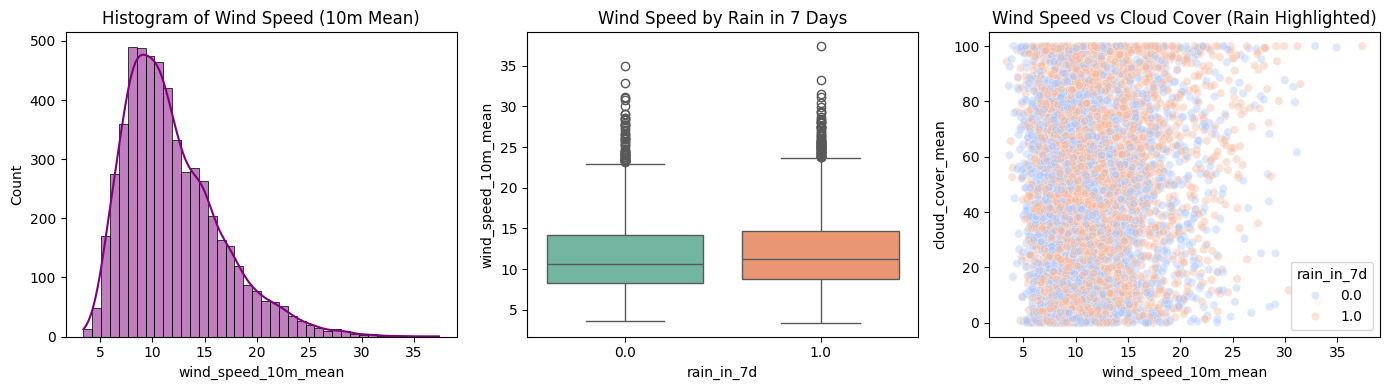

In [38]:
plt.figure(figsize=(14,4))

# Histogram
plt.subplot(1,3,1)
sns.histplot(df[feat_2], bins = 40, kde = True, color = 'purple')
plt.title("Histogram of Wind Speed (10m Mean)")

# Box vs Target
plt.subplot(1,3,2)
sns.boxplot(x = target_name, y = feat_2, data = df, palette = 'Set2')
plt.title("Wind Speed by Rain in 7 Days")

# Scatter vs Cloud Cover
plt.subplot(1,3,3)
sns.scatterplot(x = feat_2, y = 'cloud_cover_mean', hue = target_name, data = df, alpha = 0.4, palette = 'coolwarm')
plt.title("Wind Speed vs Cloud Cover (Rain Highlighted)")

plt.tight_layout()
plt.show()


In [39]:
# <Student to fill this section>
feature_3_insights = """
The histogram shows a right-skewed distribution of wind speeds, mostly between 8–15 m/s with a peak around 10 m/s, while speeds above 25 m/s are rare. Rainy days 
exhibit slightly higher wind speeds, wider spreads, and occasional high-wind outliers, indicating that stronger winds often coincide with storms. Scatterplots reveal 
that rain cases cluster at higher cloud cover and moderate-to-strong wind speeds, highlighting the interaction between wind and cloud cover in predicting rainfall.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Data Preparation for Modeling

In [41]:
# Create the features 'X' and target variable 'y' from the custom package
X, y = pop_target(df = df, target_col = target_name)

In [42]:
# Splitting the dataset into training, validation and test sets from the custom package
X_train_val, y_train_val, X_test, y_test = data_splitting_based_on_time(X = X, y = y, date_col = 'date', test_size = 0.2, random_state = 42)

In [43]:
# Splitting the train_val dataset into training and validation sets from the custom package
X_train, y_train, X_val, y_val = data_splitting_based_on_time(X = X_train_val, y = y_train_val, date_col = 'date', test_size = 0.2, random_state = 42)

In [44]:
# Create the training, validation and test dataframe
train_df = pd.concat([X_train, y_train], axis = 1)
val_df = pd.concat([X_val, y_val], axis = 1)
test_df = pd.concat([X_test, y_test], axis = 1)

In [45]:
# Save all datasets
try:
  train_df.to_csv("../../data/raw/rain_or_not/train.csv", index=False)
  val_df.to_csv("../../data/raw/rain_or_not/val.csv", index=False)
  test_df.to_csv("../../data/raw/rain_or_not/test.csv", index=False)
except Exception as e:
  print(e)

In [6]:
# # In case, you want to start from imported datasets, then uncomment this block

# # Import all datasets
# train_df = pd.read_csv("../../data/raw/rain_or_not/train.csv")
# val_df = pd.read_csv("../../data/raw/rain_or_not/val.csv")
# test_df = pd.read_csv("../../data/raw/rain_or_not/test.csv")

# # Ensure date is of type datetime
# train_df['date'] = pd.to_datetime(train_df['date'], utc=True)
# val_df['date'] = pd.to_datetime(val_df['date'], utc=True)
# test_df['date'] = pd.to_datetime(test_df['date'], utc=True)

# # Define target name
# target_name = "rain_in_7d"

# # Create features and target for each dataset

# X_train, y_train = pop_target(df = train_df, target_col = target_name)
# X_val, y_val = pop_target(df = val_df, target_col = target_name)
# X_test, y_test = pop_target(df = test_df, target_col = target_name)

---
## E. Feature Selection


### E.1 Approach `Removal of correlated features`


In [46]:
# Compute correlation matrix for numeric features
corr_matrix = X_train.corr(numeric_only=True)

In [47]:
# Upper triangle mask to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [48]:
# Features with correlation > 0.9
highly_correlated_features = [column for column in upper.columns if any(upper[column].abs() > 0.90)]
highly_correlated_features

['apparent_temperature_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'wet_bulb_temperature_2m_mean',
 'wet_bulb_temperature_2m_max',
 'wet_bulb_temperature_2m_min',
 'dew_point_2m_mean',
 'pressure_msl_max',
 'pressure_msl_min',
 'surface_pressure_mean',
 'et0_fao_evapotranspiration']

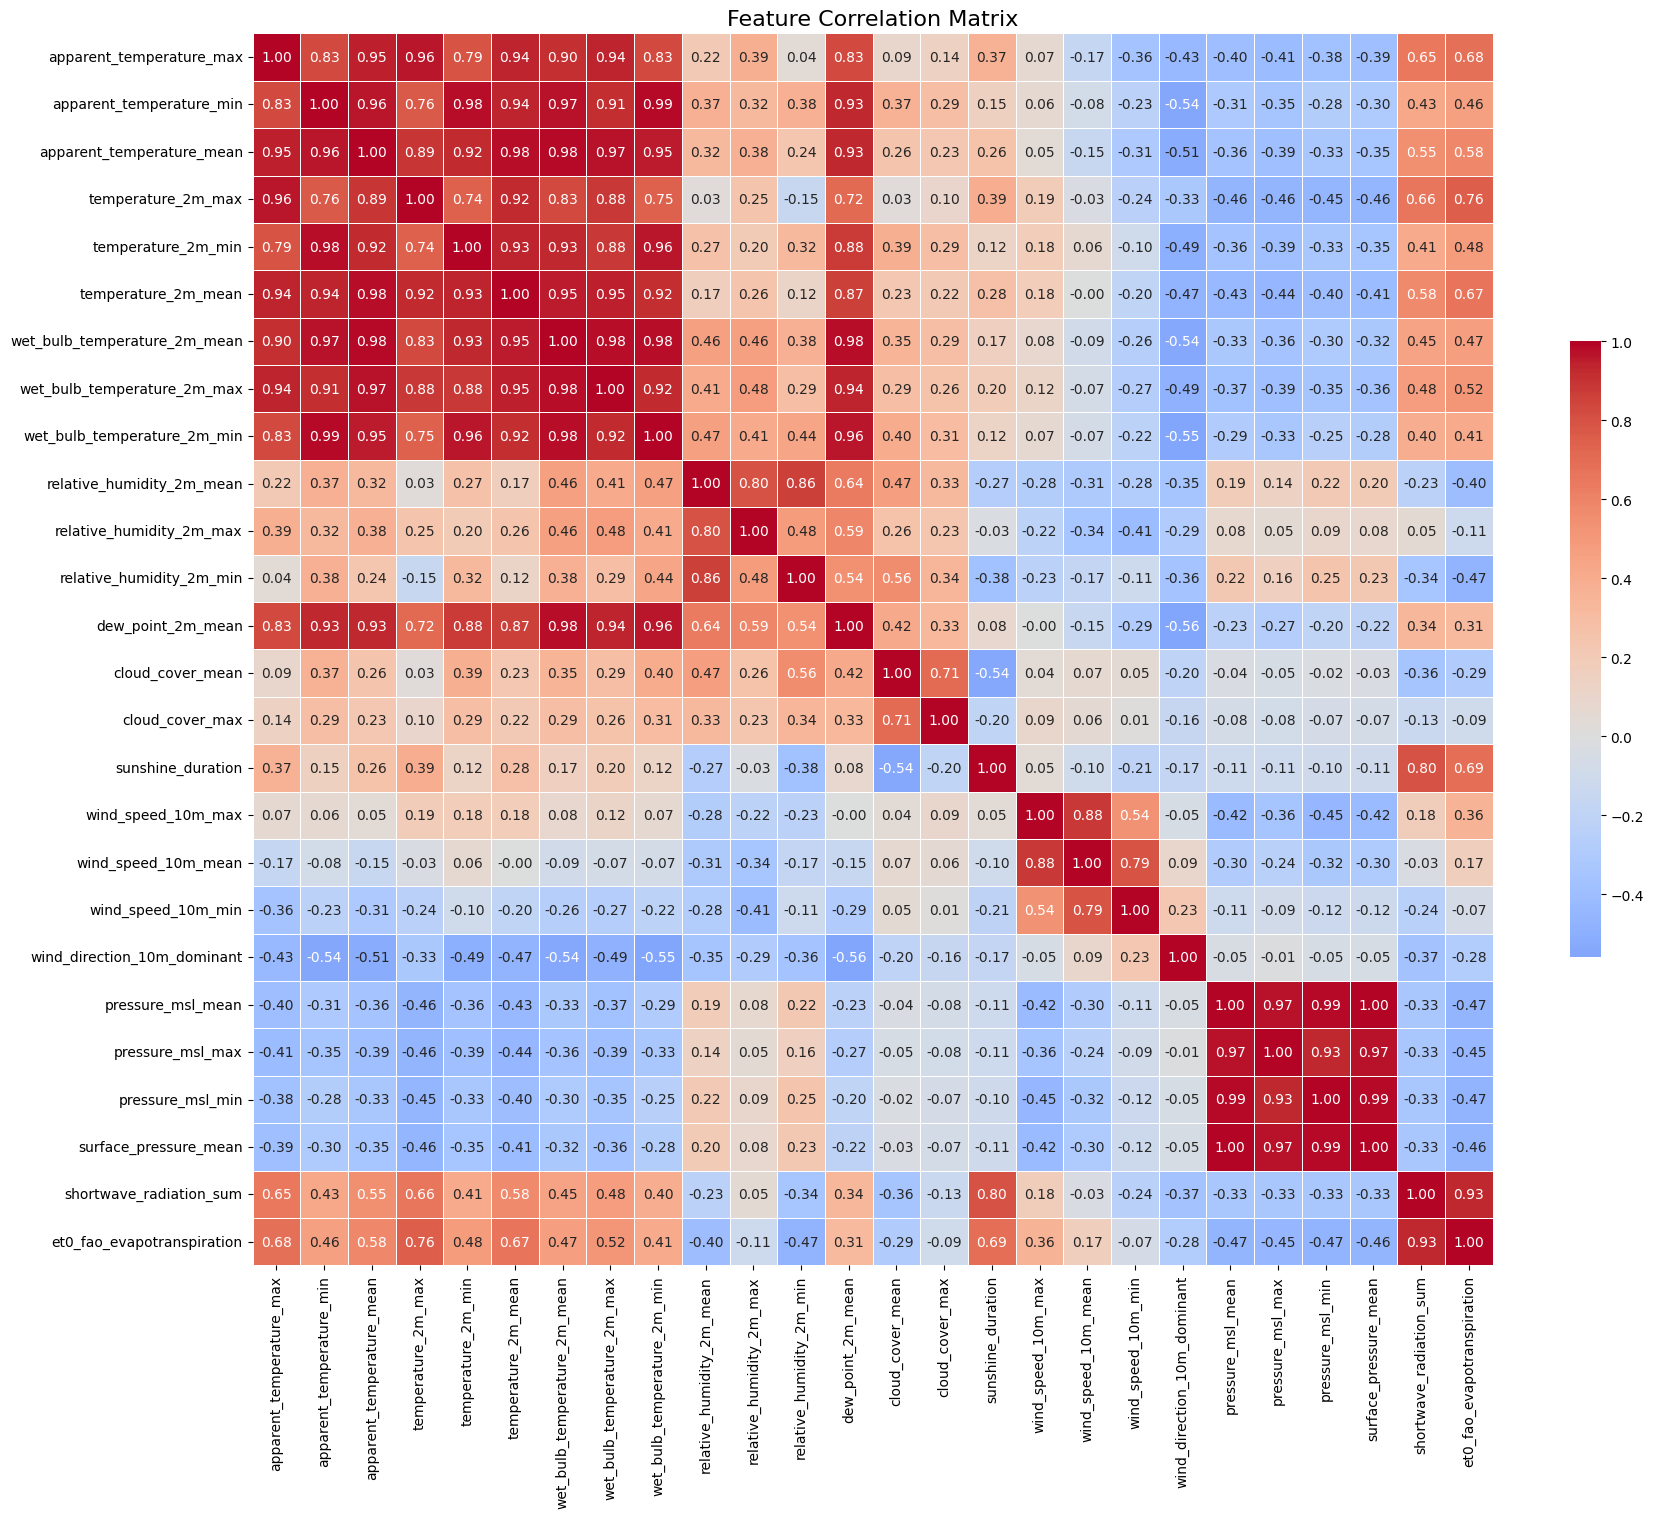

In [49]:
# Plot the correlation matrix
plot_correlation_matrix(corr_matrix, figsize = (20, 16), cmap = "coolwarm", title = "Feature Correlation Matrix")

In [50]:
# <Student to fill this section>
feature_selection_1_insights = """
Highly correlated features introduce redundancy and multicollinearity, which can distort model learning. By removing features with correlation above 0.9, only unique 
predictors were retained, ensuring more stable coefficients and reducing overfitting risks while maintaining predictive power.
"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### E.2 Approach "Removal of Low-Importance Features"


In [52]:
# col not in highly_correlated_features
selected_features = [ col for col in X_train.columns if col != "date" ]

X_train_selected = X_train[selected_features]

In [53]:
# ANOVA F-test
selector = SelectKBest(score_func = f_classif, k = 10)
selector.fit(X_train_selected, y_train)
anova_scores = pd.Series(selector.scores_, index = X_train_selected.columns).sort_values(ascending = False)

In [54]:
print("ANOVA Scores:\n", anova_scores)

ANOVA Scores:
 wet_bulb_temperature_2m_mean    102.340533
wet_bulb_temperature_2m_min     101.948410
wet_bulb_temperature_2m_max      95.861350
temperature_2m_mean              95.293583
dew_point_2m_mean                94.893674
temperature_2m_min               94.330578
apparent_temperature_min         94.197577
apparent_temperature_mean        93.767515
apparent_temperature_max         75.056466
temperature_2m_max               66.785083
wind_direction_10m_dominant      51.512059
et0_fao_evapotranspiration       41.590204
shortwave_radiation_sum          40.051135
wind_speed_10m_max               21.557702
relative_humidity_2m_max         17.491138
pressure_msl_max                 17.321705
surface_pressure_mean            15.849722
relative_humidity_2m_mean        15.736225
relative_humidity_2m_min         10.264294
cloud_cover_mean                  8.978661
pressure_msl_mean                 8.637771
wind_speed_10m_mean               7.833828
sunshine_duration                 7.224

In [55]:
# Sort the columns based on descending ANOVA scores
anova_filtered = anova_scores.loc[selected_features].sort_values(ascending=False)

In [56]:
# Classify features with F-scores < 5 as low_importance_features
low_importance_features = anova_filtered[anova_filtered < 5].index.tolist()
low_importance_features

['cloud_cover_max', 'wind_speed_10m_min', 'pressure_msl_min']

In [57]:
# <Student to fill this section>
feature_selection_2_insights = """
Low F-scores indicate weak relationships with the target. Removing features below this threshold filters out irrelevant variables, improving model interpretability and 
efficiency. This approach ensured only predictors with meaningful statistical association to rainfall were retained, strengthening model focus and reducing noise.
"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## E.3 Final Selection of Features

In [59]:
# Create a list consisting of all the features to remove

features_to_remove = highly_correlated_features + low_importance_features
features_to_remove

['apparent_temperature_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'wet_bulb_temperature_2m_mean',
 'wet_bulb_temperature_2m_max',
 'wet_bulb_temperature_2m_min',
 'dew_point_2m_mean',
 'pressure_msl_max',
 'pressure_msl_min',
 'surface_pressure_mean',
 'et0_fao_evapotranspiration',
 'cloud_cover_max',
 'wind_speed_10m_min',
 'pressure_msl_min']

In [60]:
# Creating the final features list 

features_list = [col for col in X_train.columns.tolist() if col not in features_to_remove]
features_list

['date',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'relative_humidity_2m_mean',
 'relative_humidity_2m_max',
 'relative_humidity_2m_min',
 'cloud_cover_mean',
 'sunshine_duration',
 'wind_speed_10m_max',
 'wind_speed_10m_mean',
 'wind_direction_10m_dominant',
 'pressure_msl_mean',
 'shortwave_radiation_sum']

In [61]:
# Add the target variable to the list of selected features
features_list.append(target_name)

In [62]:
# <Student to fill this section>
feature_selection_explanations = """
The chosen features capture key atmospheric conditions influencing rainfall, including temperature extremes, humidity variations, cloud cover, sunshine, wind patterns, 
pressure, and radiation. Together, they represent a balanced mix of thermal, moisture, and dynamic variables critical for predicting rain occurrence seven days ahead in Sydney.
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## F. Data Cleaning

In [64]:
# Creating a new dataframes for the purposes of data cleaning
train_clean = train_df[features_list]
val_clean = val_df[features_list]
test_clean = test_df[features_list]

### F.1 Data Cleaning `Handling Null Values`

In [65]:
# Checking for null values in the training dataset
train_clean.isnull().sum()

date                           0
apparent_temperature_max       0
apparent_temperature_min       0
relative_humidity_2m_mean      0
relative_humidity_2m_max       0
relative_humidity_2m_min       0
cloud_cover_mean               0
sunshine_duration              0
wind_speed_10m_max             0
wind_speed_10m_mean            0
wind_direction_10m_dominant    0
pressure_msl_mean              0
shortwave_radiation_sum        0
rain_in_7d                     0
dtype: int64

In [66]:
# Checking for null values in the validation dataset
val_clean.isnull().sum()

date                           0
apparent_temperature_max       0
apparent_temperature_min       0
relative_humidity_2m_mean      0
relative_humidity_2m_max       0
relative_humidity_2m_min       0
cloud_cover_mean               0
sunshine_duration              0
wind_speed_10m_max             0
wind_speed_10m_mean            0
wind_direction_10m_dominant    0
pressure_msl_mean              0
shortwave_radiation_sum        0
rain_in_7d                     0
dtype: int64

In [67]:
# Checking for null values in the test dataset
test_clean.isnull().sum()

date                           0
apparent_temperature_max       0
apparent_temperature_min       0
relative_humidity_2m_mean      0
relative_humidity_2m_max       0
relative_humidity_2m_min       0
cloud_cover_mean               0
sunshine_duration              0
wind_speed_10m_max             0
wind_speed_10m_mean            0
wind_direction_10m_dominant    0
pressure_msl_mean              0
shortwave_radiation_sum        0
rain_in_7d                     7
dtype: int64

In [68]:
# Features list to impute
impute_feat = [col for col in train_clean.columns if col not in ["date", target_name]]
impute_feat

['apparent_temperature_max',
 'apparent_temperature_min',
 'relative_humidity_2m_mean',
 'relative_humidity_2m_max',
 'relative_humidity_2m_min',
 'cloud_cover_mean',
 'sunshine_duration',
 'wind_speed_10m_max',
 'wind_speed_10m_mean',
 'wind_direction_10m_dominant',
 'pressure_msl_mean',
 'shortwave_radiation_sum']

In [69]:
# Create a column transformer to handle null values

class NumericImputerWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features
        self.imputer = SimpleImputer(strategy="median")
        
    def fit(self, X, y=None):
        self.imputer.fit(X[self.features])
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.features] = self.imputer.transform(X_copy[self.features])
        return X_copy

In [70]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Handling null values ensures the model receives complete and consistent data, preventing errors during training and improving prediction 
reliability. Dropping or imputing missing entries maintains data integrity, reduces bias, and allows the algorithms to learn meaningful 
without distortions from incomplete records.
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### F.2 Data Cleaning `Handling Duplicate Values`

In [72]:
# Check the number of duplicate values in the training set
train_clean.duplicated().sum()

np.int64(0)

In [73]:
# Check the number of duplicate values in the validation set
val_clean.duplicated().sum()

np.int64(0)

In [74]:
# Check the number of duplicate values in the test set
test_clean.duplicated().sum()

np.int64(0)

In [75]:
# Create a custom-transformer to handle duplicates

class DuplicateHandler(BaseEstimator, TransformerMixin):
    # To determine whether the index should be reset after dropping duplicates
    def __init__(self, reset_index=True):
        self.reset_index = reset_index

    # Created solely to comply with scikit-learn's API, as removing duplicates doesn't require fitting or learning from the data.
    def fit(self, X, y=None):
        return self
    
    # Remove the duplicates from the dataframe and optionally reset the index
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        X_clean = X.drop_duplicates()
        if self.reset_index:
            X_clean = X_clean.reset_index(drop=True)
        return X_clean

In [76]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Removing duplicate records prevents the model from being biased toward repeated observations, which could otherwise skew feature importance and 
evaluation metrics. Ensuring each observation is unique improves generalization, enhances training stability, and produces more trustworthy and 
representative predictions for real-world applications.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### F.3 Data Cleaning `Handling Outlier Values`

In [78]:
# Identify the numeric and categorical features in the dataset from the custom package
numerical_features, categorical_features = return_numerical_categorical_features(df = train_clean, target_col = target_name)

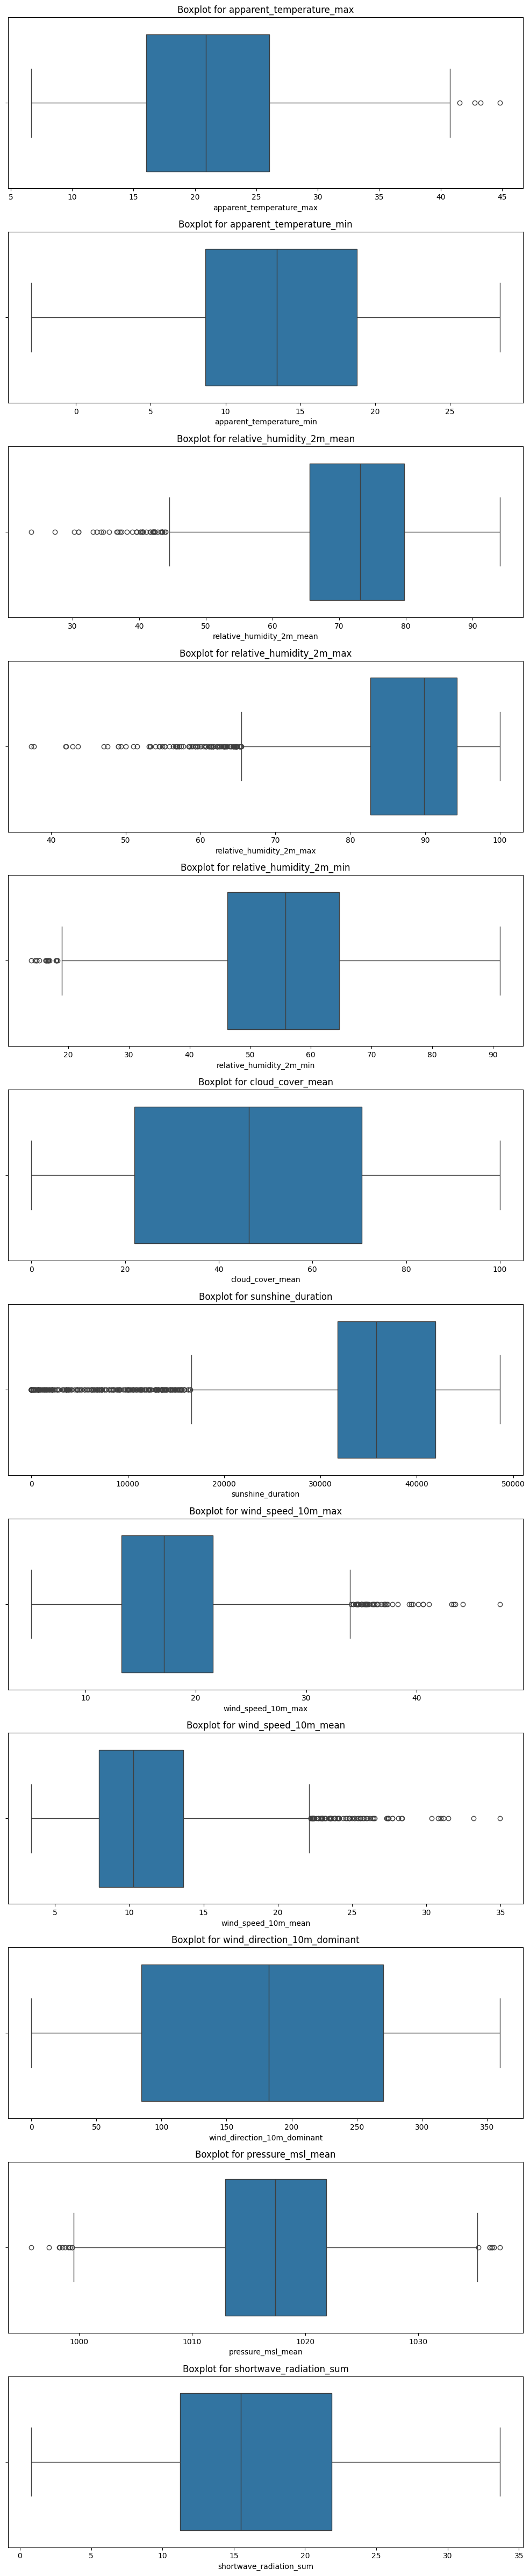

In [79]:
# Plotting the box plot for every numerical feature to identify outliers

plot_boxplots(data = train_clean, columns = numerical_features, figsize=(10, 5), per_col_height=4)

In [80]:
# Create a list of the outlier features
outlier_features = ["relative_humidity_2m_mean", "relative_humidity_2m_max", "wind_speed_10m_mean", "sunshine_duration", "wind_speed_10m_max"]

In [81]:
# Create a custom-style transformer to handle outliers

class OutlierHandler(BaseEstimator, TransformerMixin):

    # To initialise with optional feature list and IQR factor for outlier detection
    def __init__(self, features=None, factor=3.0):
        self.features = features
        self.factor = factor
        self.bounds_ = {}

    # Compute IQR-based lower and upper bounds for each specified feature
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        feats = self.features if self.features is not None else X_df.columns

        for feat in feats:
            q1 = X_df[feat].quantile(0.25)
            q3 = X_df[feat].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - self.factor * iqr
            upper = q3 + self.factor * iqr
            self.bounds_[feat] = (lower, upper)
        return self

    # Clip values outside the IQR bounds to reduce outlier impact
    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for feat, (lower, upper) in self.bounds_.items():
            X_df[feat] = np.clip(X_df[feat], lower, upper)
        return X_df

In [82]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Winsorizing outliers reduces the impact of extreme values that can disproportionately influence model parameters. This step stabilizes 
training, mitigates overfitting risks, and ensures predictions reflect typical conditions rather than rare, extreme cases, improving 
overall robustness and reliability of both classification and regression models.
"""

In [83]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### F.4 Data Cleaning Pipeline

In [84]:
# Create a pipeline for data cleaning
cleaning_pipeline = Pipeline(steps=[
    ("imputer", NumericImputerWrapper(impute_feat)),
    ("remove_duplicates", DuplicateHandler(reset_index=True)),
    ("outlier_handler", OutlierHandler(features=outlier_features, factor=3.0))
])

In [85]:
print(cleaning_pipeline)

Pipeline(steps=[('imputer',
                 NumericImputerWrapper(features=['apparent_temperature_max',
                                                 'apparent_temperature_min',
                                                 'relative_humidity_2m_mean',
                                                 'relative_humidity_2m_max',
                                                 'relative_humidity_2m_min',
                                                 'cloud_cover_mean',
                                                 'sunshine_duration',
                                                 'wind_speed_10m_max',
                                                 'wind_speed_10m_mean',
                                                 'wind_direction_10m_dominant',
                                                 'pressure_msl_mean',
                                                 'shortwave_radiation_sum'])),
                ('remove_duplicates', DuplicateHandler()),
                

In [86]:
# Fit and transform the training and validation set using the pipeline
train_clean = cleaning_pipeline.fit_transform(train_clean)
val_clean = cleaning_pipeline.transform(val_clean)

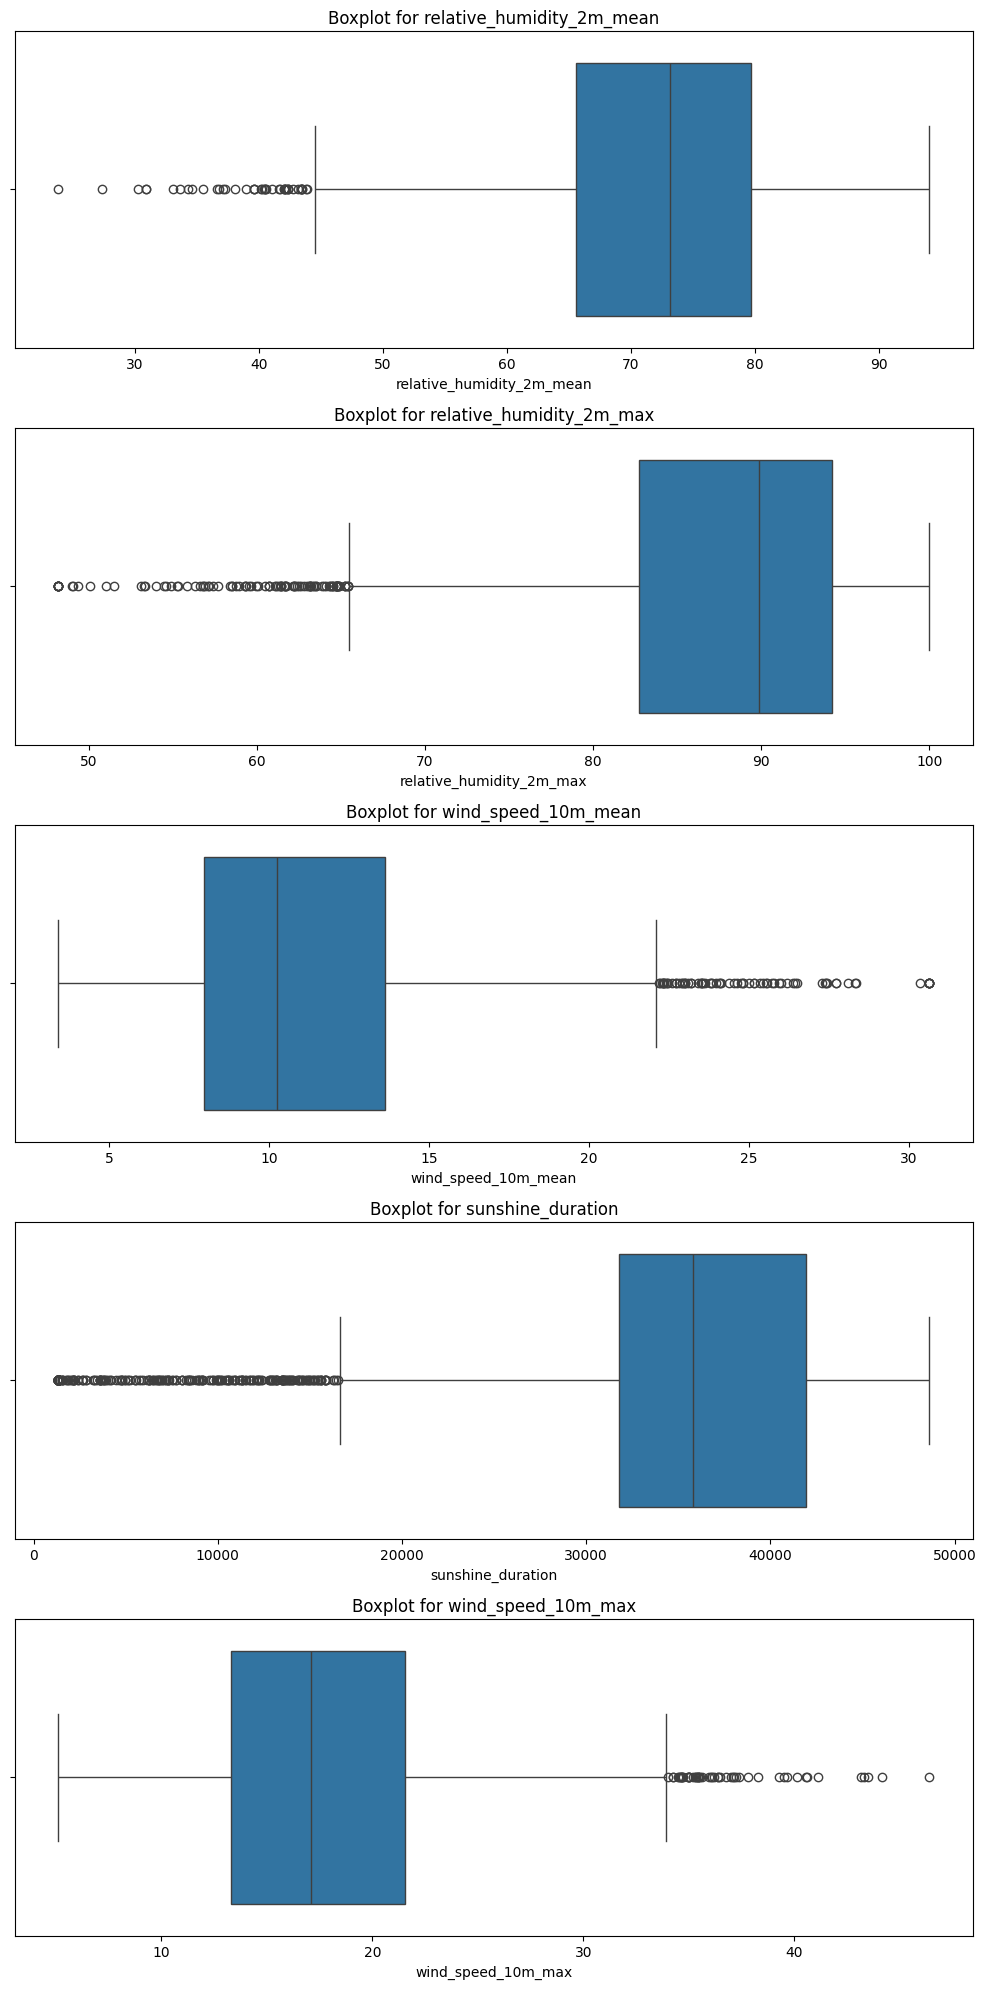

In [87]:
# Plot the outlier features after cleaning

plot_boxplots(data = train_clean, columns = outlier_features, figsize=(10, 5), per_col_height=4)


---
## G. Feature Engineering

In [88]:
# Create copies of the train, validation and test sets
train_eng = train_clean.copy()
val_eng = val_clean.copy()

### G.1 New Feature `Temperature Range`


In [89]:
# Create a custom column - style transformer pipeline instance for Temperature Range

class TempRangeAdder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None): 
        return self

    # Create a new feature 'temp_range' as the difference between max and min apparent temperature
    def transform(self, X):
        X = X.copy()
        X["temp_range"] = X["apparent_temperature_max"] - X["apparent_temperature_min"]
        return X

In [90]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Capturing the daily temperature range highlights thermal variability, which can influence atmospheric instability and cloud formation. Including this feature helps the 
model detect patterns associated with rain likelihood, improving prediction accuracy beyond simple mean or max/min temperature values.
"""

In [91]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### G.2 New Feature `Humidity Spread`




In [92]:
# Create a custom column - style transformer pipeline instance for Humidity Spread

class HumidityRangeAdder(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self

    # Create a new feature 'humidity_range' as the difference between max and min relative humidity
    def transform(self, X):
        X = X.copy()
        X["humidity_range"] = X["relative_humidity_2m_max"] - X["relative_humidity_2m_min"]
        return X

In [93]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The spread in relative humidity provides insights into moisture fluctuations throughout the day. Larger variability often correlates with condensation and 
precipitation potential, making it a useful predictor of rain occurrence within the next seven days.
"""

In [94]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### G.3 New Feature `Monthly and Seasonal Capture`

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [95]:
# Create a custom column - style transformer pipeline instance for capturing monthly and seasonal features

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self

    # Create new features 'month' and 'season' from the 'date'
    def transform(self, X):
        X = X.copy()

        # Convert 'date' column to datetime if not already
        if not pd.api.types.is_datetime64_any_dtype(X["date"]):
            X["date"] = pd.to_datetime(X["date"], errors="coerce")

        # Extract month from date
        X["month"] = X["date"].dt.month

        # Derive season from month
        def get_season(month):
            if month in [12, 1, 2]:
                return "Summer"
            elif month in [3, 4, 5]:
                return "Autumn"
            elif month in [6, 7, 8]:
                return "Winter"
            else:
                return "Spring"
        
        X["season"] = X["month"].apply(get_season)
        X.drop(columns = "date", inplace = True)
        return X


In [96]:
# <Student to fill this section>
feature_engineering_3_explanations = """
Incorporating month and derived season captures cyclical and seasonal rainfall patterns. Rain likelihood varies across months, and encoding this information 
helps the model learn temporal trends, enhancing its ability to generalize and predict rain events accurately throughout the year.
"""

In [97]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### G.4 Feature Engineering Pipeline


In [98]:
# Create a pipeline for feature engineering
eng_pipeline = Pipeline([
    ("temp_range", TempRangeAdder()),
    ("humidity_range", HumidityRangeAdder()),
    ("date_features", DateFeatureExtractor()),
])

In [99]:
print(eng_pipeline)

Pipeline(steps=[('temp_range', TempRangeAdder()),
                ('humidity_range', HumidityRangeAdder()),
                ('date_features', DateFeatureExtractor())])


In [100]:
# Fit and transform the training and validation set using the pipeline
train_eng = eng_pipeline.fit_transform(train_clean)
val_eng   = eng_pipeline.transform(val_clean)

---
## H. Data Preparation for Modeling

### H.1 Split Datasets

In [101]:
# Dataset splitting using function from custom package
X_train, y_train = pop_target(train_eng, target_name)
X_val, y_val = pop_target(val_eng, target_name)

In [102]:
# <Student to fill this section>
data_splitting_explanations = """
For this dataset, a time-based split is ideal, using earlier years for training and the most recent data (2025) for testing. This approach preserves temporal order, 
prevents data leakage, and ensures the model is evaluated on future, unseen conditions, reflecting real-world forecasting scenarios accurately.
"""

In [103]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### H.2 Data Transformation `Cyclic Encoding of 'month'`

In [104]:
# Create a custom column - style transformer pipeline instance which performs cyclic encoding for 'months'

class MonthCyclicEncoder(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None): 
        return self
        
    def transform(self, X):
        X = X.copy()
        X['month_sin'] = np.sin(2 * np.pi * X['month']/12)
        X['month_cos'] = np.cos(2 * np.pi * X['month']/12)
        X = X.drop(columns=['month'])
        return X

In [105]:
# <Student to fill this section>
data_transformation_1_explanations = """
Encoding months cyclically captures seasonal trends without introducing artificial discontinuities between December and January, 
enhancing the model’s ability to learn temporal effects
"""

In [106]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### H.3 Data Transformation `Categorical Encoding for Seasons`

In [107]:
# <Student to fill this section>
# Identify the numeric and categorical features in the dataset from the custom package
numerical_features, categorical_features = return_numerical_categorical_features(df = X_train, target_col = target_name)
categorical_features

['season']

In [108]:
# Create a custom column - style transformer pipeline instance which performs one-hot encoding for categorical features

class SeasonOHEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_features):
        self.categorical_features = categorical_features
        self.ohe = OneHotEncoder(drop='first', sparse_output=False)
        self.encoded_cols = None

    def fit(self, X, y=None):
        self.ohe.fit(X[self.categorical_features])
        self.encoded_cols = self.ohe.get_feature_names_out(self.categorical_features)
        return self

    def transform(self, X):
        X = X.copy()
        X_encoded_arr = self.ohe.transform(X[self.categorical_features])
        X_encoded = pd.DataFrame(X_encoded_arr, columns=self.encoded_cols, index=X.index)
        X = X.drop(columns=self.categorical_features)
        X = pd.concat([X, X_encoded], axis=1)
        return X

In [109]:
# <Student to fill this section>
data_transformation_2_explanations = """
One-hot encodes seasonal categories, enabling the model to leverage categorical seasonal effects without assuming ordinal relationships, improving regression accuracy.
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### H.4 Data Transformation `Standarisation`

In [111]:
# Create a custom column - style transformer pipeline instance which performs standarisation on numerical features

class NumericStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_suffixes=['_sin', '_cos']):
        self.exclude_suffixes = exclude_suffixes
        self.scaler = StandardScaler()
        self.numeric_features = None

    def fit(self, X, y=None):
        self.numeric_features = [c for c in X.columns if not any(c.endswith(suf) for suf in self.exclude_suffixes)]
        self.scaler.fit(X[self.numeric_features])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.numeric_features] = self.scaler.transform(X[self.numeric_features])
        return X

In [112]:
numeric_features = [c for c in X_train.columns if not (c.endswith("_sin") or c.endswith("_cos"))]
numeric_features

['apparent_temperature_max',
 'apparent_temperature_min',
 'relative_humidity_2m_mean',
 'relative_humidity_2m_max',
 'relative_humidity_2m_min',
 'cloud_cover_mean',
 'sunshine_duration',
 'wind_speed_10m_max',
 'wind_speed_10m_mean',
 'wind_direction_10m_dominant',
 'pressure_msl_mean',
 'shortwave_radiation_sum',
 'temp_range',
 'humidity_range',
 'month',
 'season']

In [113]:
# <Student to fill this section>
data_transformation_3_explanations = """
Scales numeric features to a common range, reducing bias from variables with large magnitudes. This stabilises gradient-based algorithms 
and improves convergence, ensuring all features contribute proportionally to model training.
"""

In [114]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### H.5 Data Transformation Pipeline

In [115]:
# Create a pipeline for data transformation

data_transform_pipeline = Pipeline([
    ('cyclic_month', MonthCyclicEncoder()),
    ('ohe_season', SeasonOHEEncoder(categorical_features=categorical_features)),
    ('scaler', NumericStandardScaler())
])

In [116]:
print(data_transform_pipeline)

Pipeline(steps=[('cyclic_month', MonthCyclicEncoder()),
                ('ohe_season',
                 SeasonOHEEncoder(categorical_features=['season'])),
                ('scaler', NumericStandardScaler())])


In [117]:
# Fit and transform the training and validation set using the pipeline

X_train = data_transform_pipeline.fit_transform(X_train)
X_val   = data_transform_pipeline.transform(X_val)

---
## I. Save Datasets

> Do not change this code

In [118]:
# Do not modify this code
# Save all datasets
try:
  X_train.to_csv("../../data/processed/rain_or_not/X_train.csv", index=False)
  y_train.to_csv("../../data/processed/rain_or_not/y_train.csv", index=False)

  X_val.to_csv("../../data/processed/rain_or_not/X_val.csv", index=False)
  y_val.to_csv("../../data/processed/rain_or_not/y_val.csv", index=False)
except Exception as e:
  print(e)

---
## J. Selection of Performance Metrics

> Accuracy, F1-score, ROC, and AUC were chosen as they evaluate both overall correctness and balance between precision and recall, which is crucial for predicting rare rain 
events. ROC and AUC further assess the model’s discrimination ability, ensuring reliable classification performance across thresholds.


In [119]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_curve, auc

In [120]:
# <Student to fill this section>
performance_metrics_explanations = """
Accuracy, F1-score, ROC, and AUC were chosen as they evaluate both overall correctness and balance between precision and recall, which is crucial for predicting rare rain 
events. ROC and AUC further assess the model’s discrimination ability, ensuring reliable classification performance across thresholds.
"""

In [121]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## K. Train Machine Learning Model

### K.1 Import Algorithm

> Logistic Regression provides a simple, interpretable baseline for binary classification, while Random Forest captures non-linear interactions and complex patterns in the data. 
Combining both allows comparison between linear and non-linear approaches, ensuring robust prediction of rainfall occurrence in Sydney.


In [122]:
# <Student to fill this section>
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [123]:
# Dummy Classifier with most frequent strategy
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_val)

print("Accuracy of baseline model: ", accuracy_score(y_val, y_pred))
print("F1-Score of baseline model: ", f1_score(y_val, y_pred))

Accuracy of baseline model:  0.4241733181299886
F1-Score of baseline model:  0.0


In [124]:
# <Student to fill this section>
algorithm_selection_explanations = """
Logistic Regression provides a simple, interpretable baseline for binary classification, while Random Forest captures non-linear interactions and complex patterns in the data. 
Combining both allows comparison between linear and non-linear approaches, ensuring robust prediction of rainfall occurrence in Sydney.
"""

In [125]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### K.2 Set Hyperparameters

> Hyperparameter tuning optimizes model performance by adjusting key settings. For Logistic Regression, fit_intercept and C control model bias and regularization strength. 
For Random Forest, parameters like n_estimators, max_depth, and min_samples_leaf influence tree complexity, ensemble diversity, and generalization, balancing underfitting and 
overfitting.


In [126]:
# Declare the hyper-parameters that will be used by Logistic Regression

param_grid_lr = {
    "fit_intercept": [True, False],
    "C": [0.01, 0.1, 1, 10],
}

In [127]:
# Declare the hyper-parameters that will be used by Random Forest

param_grid_rf = {
    "n_estimators": [100, 200, 350, 500],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [128]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Hyperparameter tuning optimizes model performance by adjusting key settings. For Logistic Regression, fit_intercept and C control model bias and regularization strength. 
For Random Forest, parameters like n_estimators, max_depth, and min_samples_leaf influence tree complexity, ensemble diversity, and generalization, balancing underfitting and 
overfitting.
"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### K.3 Fit Model

In [130]:
# Declare the instances of the two models

lr = LogisticRegression(random_state = 42)
rf = RandomForestClassifier(random_state = 42)

In [131]:
# Create the instance for parameter tuning the Logistic Regression Model

lr_search = GridSearchCV(
    estimator = lr,
    param_grid=param_grid_lr,
    cv = 5,
    scoring = "f1",
    verbose = 2,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print("Hyper-parameters of the best Logistic Regression model:", lr_search.best_params_)
print("F1 - scores for the best Logistic Regression model:", lr_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Hyper-parameters of the best Logistic Regression model: {'C': 0.1, 'fit_intercept': False}
F1 - scores for the best Logistic Regression model: 0.5941927960696134


In [132]:
# Create the instance for parameter tuning the Random Forest Model

rf_search = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_grid_rf,
    n_iter = 25,
    scoring = "f1",
    cv = 5,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

rf_search.fit(X_train, y_train)

print("Hyper-parameters of the best Random Forest model:", rf_search.best_params_)
print("F1 - scores for the best Random Forest model:", rf_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Hyper-parameters of the best Random Forest model: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 3}
F1 - scores for the best Random Forest model: 0.5568902895323934


### K.4 Model Technical Performance

> The Logistic Regression model consistently outperformed Random Forest, achieving higher F1-scores across training (0.594), validation (0.637), and test (0.697), indicating 
effective generalization. Random Forest underperformed slightly, potentially due to shallow trees limiting model complexity, suggesting mild underfitting. Overall, both models 
captured relevant patterns, with Logistic Regression showing stronger predictive capability for seven-day rain classification.


In [133]:
# Compute the performance of logistic regression on the validation set

y_pred_lr = lr_search.best_estimator_.predict(X_val)
print_classification_scores(y_pred = y_pred_lr, y_true = y_val, model_name = "Logistic Regression", dataset_type = "Validation")

Accuracy scores for the Logistic Regression model on the Validation dataset: 0.5747
F1 scores for the Logistic Regression model on the Validation dataset: 0.6368


In [134]:
# Compute the performance of random forest on the validation set

y_pred_rf = rf_search.best_estimator_.predict(X_val)
print_classification_scores(y_pred = y_pred_rf, y_true = y_val, model_name = "Random Forest", dataset_type = "Validation")

Accuracy scores for the Random Forest model on the Validation dataset: 0.5644
F1 scores for the Random Forest model on the Validation dataset: 0.5802


#### K.4 i. Evaluating the model on the Test Dataset

In [135]:
# Use only the selected features
test_clean = test_df[features_list]

# Drop all the instances for which the target variable is null
test_clean.dropna(subset=[target_name], inplace=True)

# Clean the test set using the cleaning pipeline
test_clean = cleaning_pipeline.transform(test_clean)

In [136]:
# Create the new features within the cleaned test set

test_eng = test_clean.copy()
test_eng  = eng_pipeline.transform(test_clean)

In [137]:
# Transform the features of the test set

X_test, y_test = pop_target(test_eng, target_name)
X_test  = data_transform_pipeline.transform(X_test)

In [138]:
# Compute the performance of baseline model on the test set

y_pred_test_bl = dummy.predict(X_test)
print_classification_scores(y_pred = y_pred_test_bl, y_true = y_test, model_name = "Baseline Model", dataset_type = "Test")

Accuracy scores for the Baseline Model model on the Test dataset: 0.3747
F1 scores for the Baseline Model model on the Test dataset: 0.0000


In [139]:
# Compute the performance of logistic regression on the test set

y_pred_test_lr = lr_search.best_estimator_.predict(X_test)
print_classification_scores(y_pred = y_pred_test_lr, y_true = y_test, model_name = "Logistic Regression", dataset_type = "Test")

Accuracy scores for the Logistic Regression model on the Test dataset: 0.6364
F1 scores for the Logistic Regression model on the Test dataset: 0.6972


In [140]:
# Compute the performance of random forest on the test set

y_pred_test_rf = rf_search.best_estimator_.predict(X_test)
print_classification_scores(y_pred = y_pred_test_rf, y_true = y_test, model_name = "Random Forest", dataset_type = "Test")

Accuracy scores for the Random Forest model on the Test dataset: 0.5932
F1 scores for the Random Forest model on the Test dataset: 0.6230


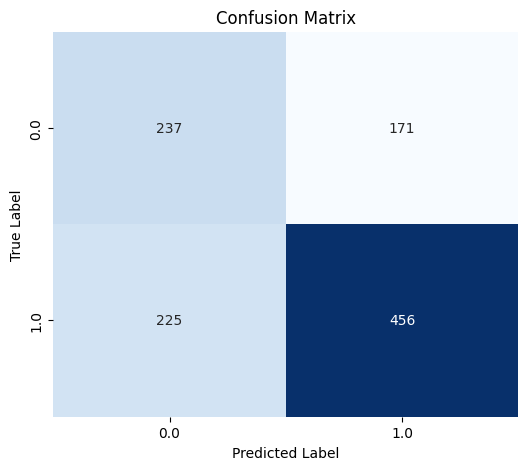

In [141]:
# Confusion Matrix for Logistic Regression model on the test set

plot_confusion_matrix(y_true = y_test, y_pred = y_pred_test_lr, labels = [0.0, 1.0])

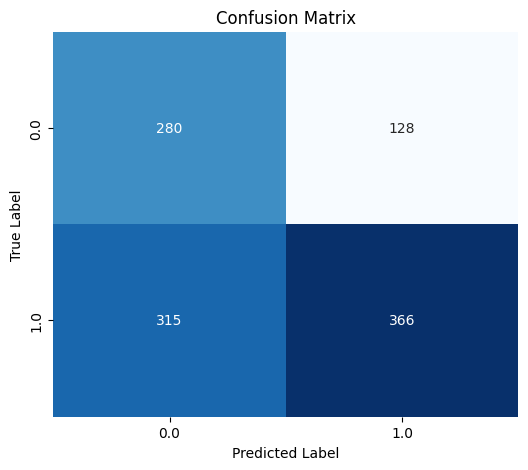

In [142]:
# Confusion Matrix for Random Forest model on the test set

plot_confusion_matrix(y_true = y_test, y_pred = y_pred_test_rf, labels = [0.0, 1.0])

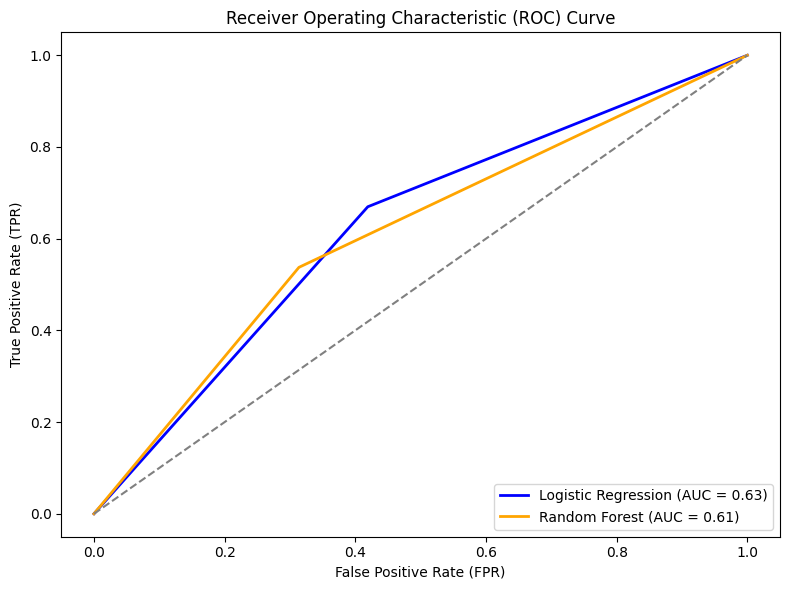

In [143]:
# Compute ROC curve and AUC for Linear Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_test_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='orange', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [144]:
# Define folder
MODEL_FOLDER = Path("../../models/rain_or_not")

# Download the processing pipelines

# Save cleaning pipeline
with open(MODEL_FOLDER / "cleaning_pipeline-experiment-1.pkl", "wb") as f:
    cloudpickle.dump(cleaning_pipeline, f)

# Save engineering pipeline
with open(MODEL_FOLDER / "eng_pipeline-experiment-1.pkl", "wb") as f:
    cloudpickle.dump(eng_pipeline, f)

# Save data transform pipeline
with open(MODEL_FOLDER / "data_transform_pipeline-experiment-1.pkl", "wb") as f:
    cloudpickle.dump(data_transform_pipeline, f)

In [ ]:
# Save the best model
best_model = lr_search.best_estimator_
joblib.dump(best_model, '../../models/rain_or_not/36120-25SP-AT2-25548684-experiment-1.joblib')

['../../models/rain_or_not/36120-25SP-AT2-25548684-experiment-1.joblib']

In [146]:
# <Student to fill this section>
model_performance_explanations = """
The Logistic Regression model consistently outperformed Random Forest, achieving higher F1-scores across training (0.594), validation (0.637), and test (0.697), indicating 
effective generalization. Random Forest underperformed slightly, potentially due to shallow trees limiting model complexity, suggesting mild underfitting. Overall, both models 
captured relevant patterns, with Logistic Regression showing stronger predictive capability for seven-day rain classification.
"""

In [147]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### K.5 Business Impact from Current Model Performance

> Accurate seven-day rain predictions directly support operational decisions in agriculture, energy, and event planning. Misclassifying rain could lead to over-irrigation, 
crop damage, or unprepared events, causing financial losses. The Logistic Regression model’s stronger performance reduces these risks, while Random Forest’s slightly lower 
accuracy could result in missed early warnings. Overall, improved forecast reliability enhances resource optimization, risk mitigation, and planning efficiency across stakeholders.


In [148]:
# <Student to fill this section>
business_impacts_explanations = """
Accurate seven-day rain predictions directly support operational decisions in agriculture, energy, and event planning. Misclassifying rain could lead to over-irrigation, 
crop damage, or unprepared events, causing financial losses. The Logistic Regression model’s stronger performance reduces these risks, while Random Forest’s slightly lower 
accuracy could result in missed early warnings. Overall, improved forecast reliability enhances resource optimization, risk mitigation, and planning efficiency across stakeholders.
"""

In [149]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## L. Project Outcomes

In [150]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Rejected - Linear models outperformed ensemble model" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [151]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [152]:
# <Student to fill this section>
experiment_results_explanations = """
The Logistic Regression model outperformed Random Forest, suggesting that linear relationships in the daily weather features sufficiently capture rainfall likelihood. This indicates 
the hypothesis that ensemble methods outperform linear models is only partially true; further experimentation with ensemble classifiers like Gradient Boosting or stacking could 
improve predictive performance. Next steps include testing ensembles with feature interactions, hyperparameter optimization, and incorporating additional temporal or lag features. 
Expected uplift is moderate (3–5% F1-score). Given the strong performance of Logistic Regression, deploying this model via the FastAPI service is recommended while iterating on
ensemble enhancements.
"""

In [153]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)